In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing    import LabelEncoder
from sklearn.utils            import compute_class_weight
from sklearn.model_selection  import StratifiedKFold
from xgboost                  import XGBClassifier


from skopt                    import BayesSearchCV

In [3]:
df = pd.read_pickle('df_clusters.pkl')

In [4]:
df.drop(columns='target_value', inplace=True)

In [5]:
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

In [6]:
# prompt: drop every column with cluster in name

# Select columns to drop based on the keyword 'cluster'
columns_to_drop = [col for col in df.columns if 'cluster' in col.lower()]

# Drop the selected columns
df.drop(columns=columns_to_drop, inplace=True)

# Print the remaining columns to verify
df.columns

Index(['adult', 'based on novel or book', 'sequel', 'superhero',
       'based on comic', 'based on a true story', 'marvel',
       'director_Mel_Gibson', 'director_Sam_Taylor_Johnson',
       'director_Rodney_Rothman',
       ...
       'genre_Fantasy', 'genre_Horror', 'genre_Western',
       'genre_Science_Fiction', 'genre_Music', 'genre_Romance',
       'genre_Adventure', 'genre_Animation', 'runtime_log', 'label'],
      dtype='object', length=227)

In [7]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

In [8]:
classes      = np.unique(df['label_enc'])
class_weights = compute_class_weight('balanced', classes=classes, y=df['label_enc'])
weight_dict   = dict(zip(classes, class_weights))
print("Wagi klas:", weight_dict)

Wagi klas: {np.int64(0): np.float64(1.2657520325203253), np.int64(1): np.float64(1.339247311827957), np.int64(2): np.float64(0.8530821917808219), np.int64(3): np.float64(0.7745646766169154)}


In [9]:
X = df.drop(['label', 'label_enc'], axis=1).values
y = df['label_enc'].values
sample_weights = np.array([ weight_dict[c] for c in y ])

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(classes),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

In [12]:
param_space = {
    'max_depth'        : (3, 10),
    'learning_rate'    : (0.01, 0.3, 'log-uniform'),
    'n_estimators'     : (50, 500),
    'subsample'        : (0.5, 1.0, 'uniform'),
    'colsample_bytree' : (0.5, 1.0, 'uniform'),
    'gamma'            : (0, 5, 'uniform'),
    'min_child_weight' : (1, 10),
    'reg_alpha'        : (1e-8, 1.0, 'log-uniform'),
    'reg_lambda'       : (1e-8, 1.0, 'log-uniform'),
}

In [13]:
bayes_search = BayesSearchCV(
    estimator    = xgb,
    search_spaces= param_space,
    n_iter       = 30,
    cv           = cv,
    scoring ='f1_macro',
    n_jobs       = -1,
    refit        = True,
    verbose      = 1
)

In [14]:
bayes_search.fit(X, y, sample_weight=sample_weights)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:52:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


BayesSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric='mlogloss',
                                      feature_types=None, gamma=None,
                                      grow_policy=None, importa...
                                      num_parallel_tree=None, ...),
              n_iter=30, n_jobs=-1, scoring='f1_macro',
              search_spaces={'colsample_bytree': (0.5, 1.0, 'uniform'),
                             'gamma': (0, 5, 'uniform'),
                             'learning_rate': (0.01, 0.3, 'log-uniform'),
                             'max_depth': (3, 10), 'min_child_weight': (1, 10),
                             'n_estimators': (50, 500),
                             'reg_alpha': (1e-08, 1.0, 'log-uniform'),
                             'reg_lambda': (1e-08, 1.0, 'log-uniform'),
                             'subsample': (0.5, 1.0, 'uniform')},
              verbose=1)

In [15]:
print("\nNajlepsze parametry:", bayes_search.best_params_)
print("Najlepszy CV log-loss:", -bayes_search.best_score_)


Najlepsze parametry: OrderedDict([('colsample_bytree', 0.5182044254217472), ('gamma', 0), ('learning_rate', 0.01), ('max_depth', 3), ('min_child_weight', 1), ('n_estimators', 317), ('reg_alpha', 5.333155362901861e-07), ('reg_lambda', 0.003462498140217215), ('subsample', 1.0)])
Najlepszy CV log-loss: -0.34073033253191837


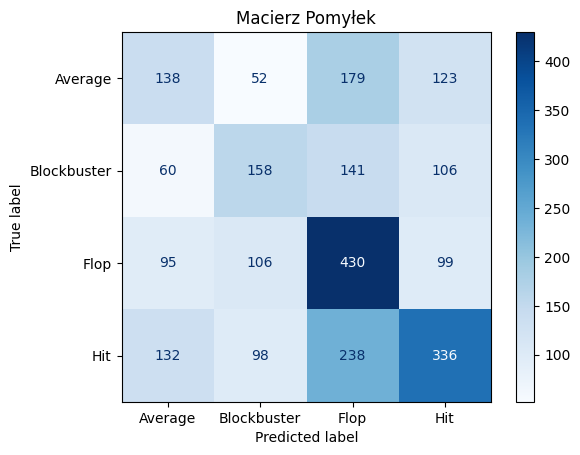

In [16]:
# prompt: wygeneruj macierz pomyłek

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the entire dataset with the best model found
y_pred = bayes_search.predict(X)

# Generate the confusion matrix
cm = confusion_matrix(y, y_pred)

# Get the class labels
class_labels = le.classes_

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Macierz Pomyłek')
plt.show()


In [17]:
# prompt: pokaz najwazniejsze miary dobroci tego modelu

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate the model
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='macro') # Use macro for multi-class
recall = recall_score(y, y_pred, average='macro') # Use macro for multi-class
f1 = f1_score(y, y_pred, average='macro') # Use macro for multi-class

print(f"\nDokładność (Accuracy): {accuracy:.4f}")
print(f"Precyzja (Precision - Macro): {precision:.4f}")
print(f"Czułość (Recall - Macro): {recall:.4f}")
print(f"Wynik F1 (F1-score - Macro): {f1:.4f}")

# Detailed classification report
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(y, y_pred, target_names=class_labels))



Dokładność (Accuracy): 0.4263
Precyzja (Precision - Macro): 0.4119
Czułość (Recall - Macro): 0.4068
Wynik F1 (F1-score - Macro): 0.4047

Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

     Average       0.32      0.28      0.30       492
 Blockbuster       0.38      0.34      0.36       465
        Flop       0.44      0.59      0.50       730
         Hit       0.51      0.42      0.46       804

    accuracy                           0.43      2491
   macro avg       0.41      0.41      0.40      2491
weighted avg       0.43      0.43      0.42      2491

